<a href="https://colab.research.google.com/github/Pavithra1912006/data-science-ex-01/blob/main/Data_science_hack_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving hospital_patient_waiting_times_100.csv to hospital_patient_waiting_times_100.csv


In [2]:
import pandas as pd

df = pd.read_csv("hospital_patient_waiting_times_100.csv")

df.head()

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type
0,P046,Orthopedics,2026-08-03 08:00,2026-08-03 08:28,2026-08-03 08:58,2026-08-03 09:15,Dr. Ravi,Monday,Follow-up
1,P094,ENT,2026-08-03 08:00,2026-08-03 08:12,2026-08-03 08:17,2026-08-03 08:36,Dr. Vijay,Monday,Follow-up
2,P022,Orthopedics,2026-08-03 08:45,2026-08-03 09:03,2026-08-03 09:45,2026-08-03 10:07,Dr. Anitha,Monday,Regular
3,P069,Pediatrics,2026-08-03 10:00,2026-08-03 10:13,2026-08-03 10:35,2026-08-03 10:52,Dr. Divya,Monday,Walk-in
4,P020,General Medicine,2026-08-03 10:15,2026-08-03 10:34,2026-08-03 11:22,2026-08-03 11:46,Dr. Meena,Monday,Regular


In [3]:
df.shape

(100, 9)

In [4]:
df.columns

Index(['Patient_ID', 'Department', 'Appointment_Time', 'Registration_Time',
       'Consultation_Time', 'Discharge_Time', 'Doctor', 'Day',
       'Appointment_Type'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         100 non-null    object
 1   Department         100 non-null    object
 2   Appointment_Time   100 non-null    object
 3   Registration_Time  100 non-null    object
 4   Consultation_Time  100 non-null    object
 5   Discharge_Time     100 non-null    object
 6   Doctor             100 non-null    object
 7   Day                100 non-null    object
 8   Appointment_Type   100 non-null    object
dtypes: object(9)
memory usage: 7.2+ KB


In [6]:
df.isnull().sum()

,0
Patient_ID,0
Department,0
Appointment_Time,0
Registration_Time,0
Consultation_Time,0
Discharge_Time,0
Doctor,0
Day,0
Appointment_Type,0


In [7]:
df["Patient_ID"].duplicated().sum()

np.int64(0)

In [8]:
time_columns = [
    "Appointment_Time",
    "Registration_Time",
    "Consultation_Time",
    "Discharge_Time"
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         100 non-null    object        
 1   Department         100 non-null    object        
 2   Appointment_Time   100 non-null    datetime64[ns]
 3   Registration_Time  100 non-null    datetime64[ns]
 4   Consultation_Time  100 non-null    datetime64[ns]
 5   Discharge_Time     100 non-null    datetime64[ns]
 6   Doctor             100 non-null    object        
 7   Day                100 non-null    object        
 8   Appointment_Type   100 non-null    object        
dtypes: datetime64[ns](4), object(5)
memory usage: 7.2+ KB


In [9]:
df["Registration_Waiting_Min"] = (
    df["Registration_Time"] - df["Appointment_Time"]
).dt.total_seconds() / 60

In [10]:
df["Doctor_Waiting_Min"] = (
    df["Consultation_Time"] - df["Registration_Time"]
).dt.total_seconds() / 60

In [11]:
df["Total_Waiting_Min"] = (
    df["Consultation_Time"] - df["Appointment_Time"]
).dt.total_seconds() / 60

In [12]:
df["Consultation_Duration_Min"] = (
    df["Discharge_Time"] - df["Consultation_Time"]
).dt.total_seconds() / 60

In [13]:
df[
    [
        "Patient_ID",
        "Appointment_Time",
        "Registration_Time",
        "Consultation_Time",
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min",
        "Consultation_Duration_Min"
    ]
].head(10)

,Patient_ID,Appointment_Time,Registration_Time,Consultation_Time,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min,Consultation_Duration_Min
0,P046,2026-08-03 08:00:00,2026-08-03 08:28:00,2026-08-03 08:58:00,28.0,30.0,58.0,17.0
1,P094,2026-08-03 08:00:00,2026-08-03 08:12:00,2026-08-03 08:17:00,12.0,5.0,17.0,19.0
2,P022,2026-08-03 08:45:00,2026-08-03 09:03:00,2026-08-03 09:45:00,18.0,42.0,60.0,22.0
3,P069,2026-08-03 10:00:00,2026-08-03 10:13:00,2026-08-03 10:35:00,13.0,22.0,35.0,17.0
4,P020,2026-08-03 10:15:00,2026-08-03 10:34:00,2026-08-03 11:22:00,19.0,48.0,67.0,24.0
5,P024,2026-08-03 10:45:00,2026-08-03 11:18:00,2026-08-03 11:37:00,33.0,19.0,52.0,22.0
6,P052,2026-08-03 11:45:00,2026-08-03 11:58:00,2026-08-03 12:31:00,13.0,33.0,46.0,17.0
7,P062,2026-08-03 12:15:00,2026-08-03 12:31:00,2026-08-03 12:44:00,16.0,13.0,29.0,24.0
8,P070,2026-08-03 14:45:00,2026-08-03 15:12:00,2026-08-03 15:21:00,27.0,9.0,36.0,40.0
9,P078,2026-08-03 16:00:00,2026-08-03 16:13:00,2026-08-03 16:25:00,13.0,12.0,25.0,7.0


In [14]:
(df["Registration_Waiting_Min"] < 0).sum()

np.int64(0)

In [15]:
(df["Doctor_Waiting_Min"] < 0).sum()

np.int64(0)

In [16]:
(df["Total_Waiting_Min"] < 0).sum()

np.int64(0)

In [17]:
check = (
    df["Registration_Waiting_Min"] +
    df["Doctor_Waiting_Min"]
)

(df["Total_Waiting_Min"] == check).all()

np.True_

In [18]:
df[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min",
        "Consultation_Duration_Min"
    ]
].describe()

,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min,Consultation_Duration_Min
count,100.000000,100.00000,100.00000,100.000000
mean,17.680000,23.08000,40.76000,18.220000
std,9.517533,11.79512,16.02909,7.416307
min,2.000000,5.00000,7.00000,7.000000
25%,11.000000,14.75000,29.75000,13.000000
50%,17.000000,24.00000,41.50000,17.000000
75%,24.000000,31.25000,52.00000,23.000000
max,49.000000,52.00000,77.00000,43.000000


In [19]:
df[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min",
        "Consultation_Duration_Min"
    ]
].mean().round(2)

,0
Registration_Waiting_Min,17.68
Doctor_Waiting_Min,23.08
Total_Waiting_Min,40.76
Consultation_Duration_Min,18.22


In [20]:
df[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min",
        "Consultation_Duration_Min"
    ]
].median().round(2)

,0
Registration_Waiting_Min,17.0
Doctor_Waiting_Min,24.0
Total_Waiting_Min,41.5
Consultation_Duration_Min,17.0


In [21]:
department_wait = df.groupby("Department")[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min"
    ]
].mean().round(2)

department_wait

,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min
Department,,,
Cardiology,15.21,31.86,47.07
Dermatology,19.21,19.36,38.57
ENT,17.57,23.93,41.50
General Medicine,20.85,23.00,43.85
Orthopedics,17.20,26.20,43.40
Pediatrics,14.12,15.59,29.71


In [22]:
department_wait["Total_Waiting_Min"].sort_values(ascending=False)

,Total_Waiting_Min
Department,
Cardiology,47.07
General Medicine,43.85
Orthopedics,43.40
ENT,41.50
Dermatology,38.57
Pediatrics,29.71


In [23]:
appointment_wait = df.groupby("Appointment_Type")[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min"
    ]
].mean().round(2)

appointment_wait

,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min
Appointment_Type,,,
Emergency,22.83,25.17,48.00
Follow-up,12.08,19.96,32.04
Regular,14.37,25.21,39.58
Walk-in,28.70,21.15,49.85


In [24]:
appointment_wait["Total_Waiting_Min"].sort_values(ascending=False)

,Total_Waiting_Min
Appointment_Type,
Walk-in,49.85
Emergency,48.00
Regular,39.58
Follow-up,32.04


In [25]:
df["Day_Type"] = df["Day"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

In [26]:
day_type_wait = df.groupby("Day_Type")[
    [
        "Registration_Waiting_Min",
        "Doctor_Waiting_Min",
        "Total_Waiting_Min"
    ]
].mean().round(2)

day_type_wait

,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min
Day_Type,,,
Weekday,18.48,25.92,44.39
Weekend,15.72,16.14,31.86


In [27]:
day_wait = df.groupby("Day")[
    "Total_Waiting_Min"
].mean().round(2)

day_wait.sort_values(ascending=False)

,Total_Waiting_Min
Day,
Wednesday,49.47
Tuesday,46.80
Monday,43.27
Friday,41.88
Thursday,41.50
Sunday,34.08
Saturday,30.06


In [28]:
df["Appointment_Hour"] = df["Appointment_Time"].dt.hour

In [29]:
hourly_wait = df.groupby("Appointment_Hour").agg(
    Patient_Count=("Patient_ID", "count"),
    Average_Wait=("Total_Waiting_Min", "mean")
).round(2)

hourly_wait

,Patient_Count,Average_Wait
Appointment_Hour,,
8,7,44.29
9,16,42.56
10,13,51.62
11,13,47.31
12,14,38.14
14,16,32.94
15,12,35.58
16,9,34.56


In [30]:
doctor_wait = df.groupby("Doctor").agg(
    Patient_Count=("Patient_ID", "count"),
    Average_Wait=("Total_Waiting_Min", "mean"),
    Average_Doctor_Wait=("Doctor_Waiting_Min", "mean")
).round(2)

doctor_wait.sort_values("Average_Wait", ascending=False)

,Patient_Count,Average_Wait,Average_Doctor_Wait
Doctor,,,
Dr. Kumar,5,49.40,26.40
Dr. Anitha,9,48.33,30.11
Dr. Meena,16,46.44,25.25
Dr. Suresh,5,46.00,26.80
Dr. Priya,9,45.78,34.89
Dr. Lakshmi,8,44.62,23.50
Dr. Karthik,7,44.57,27.43
Dr. Arun,10,39.70,19.40
Dr. Vijay,6,37.33,24.50


In [31]:
df["Total_Waiting_Min"].describe()

,Total_Waiting_Min
count,100.00000
mean,40.76000
std,16.02909
min,7.00000
25%,29.75000
50%,41.50000
75%,52.00000
max,77.00000


In [32]:
df.nlargest(10, "Total_Waiting_Min")[
    [
        "Patient_ID",
        "Department",
        "Appointment_Type",
        "Day",
        "Total_Waiting_Min"
    ]
]

,Patient_ID,Department,Appointment_Type,Day,Total_Waiting_Min
19,P026,ENT,Walk-in,Wednesday,77.0
97,P012,Dermatology,Emergency,Sunday,77.0
55,P041,Cardiology,Regular,Wednesday,74.0
24,P053,Pediatrics,Regular,Thursday,73.0
4,P020,General Medicine,Regular,Monday,67.0
56,P013,General Medicine,Walk-in,Wednesday,65.0
58,P079,Orthopedics,Emergency,Wednesday,63.0
68,P034,Orthopedics,Walk-in,Thursday,62.0
64,P055,General Medicine,Walk-in,Thursday,61.0
2,P022,Orthopedics,Regular,Monday,60.0


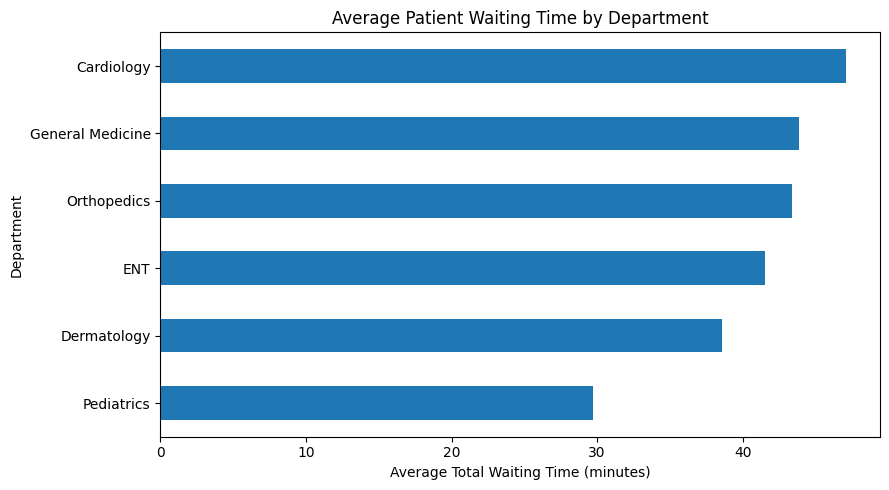

In [33]:
import matplotlib.pyplot as plt

department_plot = df.groupby("Department")["Total_Waiting_Min"].mean().sort_values()

plt.figure(figsize=(9, 5))
department_plot.plot(kind="barh")
plt.xlabel("Average Total Waiting Time (minutes)")
plt.ylabel("Department")
plt.title("Average Patient Waiting Time by Department")
plt.tight_layout()
plt.show()

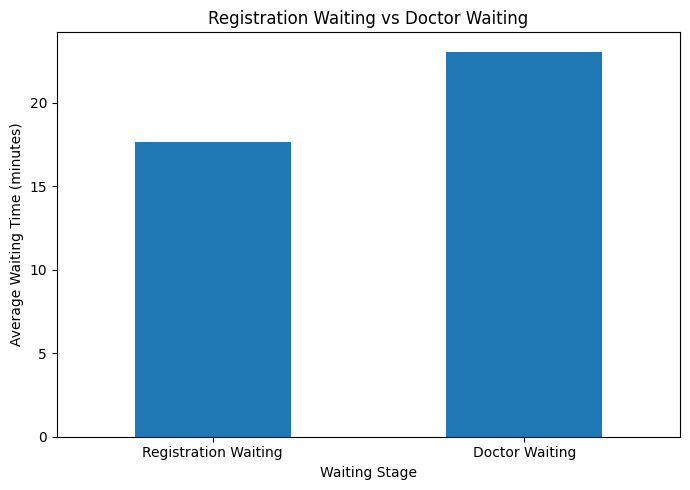

In [34]:
wait_comparison = df[
    ["Registration_Waiting_Min", "Doctor_Waiting_Min"]
].mean()

plt.figure(figsize=(7, 5))
wait_comparison.plot(kind="bar")

plt.ylabel("Average Waiting Time (minutes)")
plt.xlabel("Waiting Stage")
plt.title("Registration Waiting vs Doctor Waiting")
plt.xticks(
    ticks=[0, 1],
    labels=["Registration Waiting", "Doctor Waiting"],
    rotation=0
)
plt.tight_layout()
plt.show()

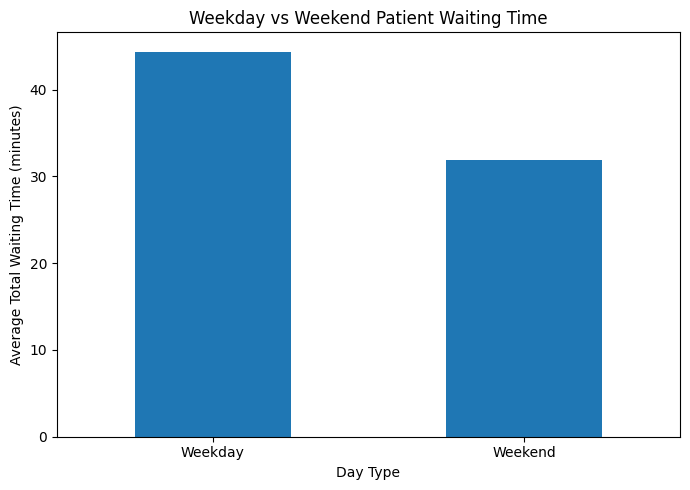

In [35]:
day_plot = df.groupby("Day_Type")["Total_Waiting_Min"].mean()

plt.figure(figsize=(7, 5))
day_plot.plot(kind="bar")

plt.xlabel("Day Type")
plt.ylabel("Average Total Waiting Time (minutes)")
plt.title("Weekday vs Weekend Patient Waiting Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

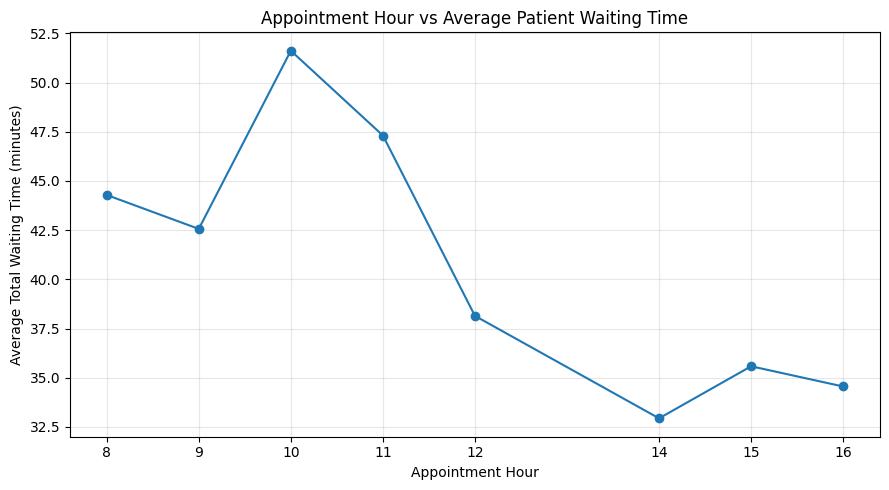

In [36]:
hour_plot = df.groupby("Appointment_Hour").agg(
    Patient_Count=("Patient_ID", "count"),
    Average_Wait=("Total_Waiting_Min", "mean")
)

plt.figure(figsize=(9, 5))
plt.plot(
    hour_plot.index,
    hour_plot["Average_Wait"],
    marker="o"
)

plt.xlabel("Appointment Hour")
plt.ylabel("Average Total Waiting Time (minutes)")
plt.title("Appointment Hour vs Average Patient Waiting Time")
plt.xticks(hour_plot.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
hour_plot

,Patient_Count,Average_Wait
Appointment_Hour,,
8,7,44.285714
9,16,42.562500
10,13,51.615385
11,13,47.307692
12,14,38.142857
14,16,32.937500
15,12,35.583333
16,9,34.555556


In [38]:
median_wait = df["Total_Waiting_Min"].median()

print("Median Waiting Time:", median_wait)

Median Waiting Time: 41.5


In [39]:
df["High_Wait"] = (
    df["Total_Waiting_Min"] > median_wait
).astype(int)

df["High_Wait"].value_counts()

,count
High_Wait,
1,50
0,50


In [40]:
features = [
    "Department",
    "Doctor",
    "Day",
    "Day_Type",
    "Appointment_Type",
    "Appointment_Hour"
]

X = df[features]
y = df["High_Wait"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Department', 'Doctor', 'Day', 'Day_Type', 'Appointment_Type', 'Appointment_Hour']

Target:
High_Wait


In [41]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Department",
        "Doctor",
        "Day",
        "Day_Type",
        "Appointment_Type"
    ],
    drop_first=True
)

X_encoded.head()

,Appointment_Hour,Department_Dermatology,Department_ENT,Department_General Medicine,Department_Orthopedics,Department_Pediatrics,Doctor_Dr. Arun,Doctor_Dr. Divya,Doctor_Dr. Karthik,Doctor_Dr. Kumar,...,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Day_Type_Weekend,Appointment_Type_Follow-up,Appointment_Type_Regular,Appointment_Type_Walk-in
0,8,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,8,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,8,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
3,10,False,False,False,False,True,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
4,10,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [42]:
print("Original features:", X.shape)
print("Encoded features:", X_encoded.shape)
print("Target:", y.shape)

Original features: (100, 6)
Encoded features: (100, 27)
Target: (100,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 80
Testing records: 20


In [44]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
High_Wait
0    40
1    40
Name: count, dtype: int64

Testing:
High_Wait
1    10
0    10
Name: count, dtype: int64


In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

In [47]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [48]:
y_pred = rf_model.predict(X_test)

print(y_pred)

[1 0 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1]


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 65.0 %


In [50]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal Wait", "High Wait"]
))

              precision    recall  f1-score   support

 Normal Wait       0.71      0.50      0.59        10
   High Wait       0.62      0.80      0.70        10

    accuracy                           0.65        20
   macro avg       0.66      0.65      0.64        20
weighted avg       0.66      0.65      0.64        20



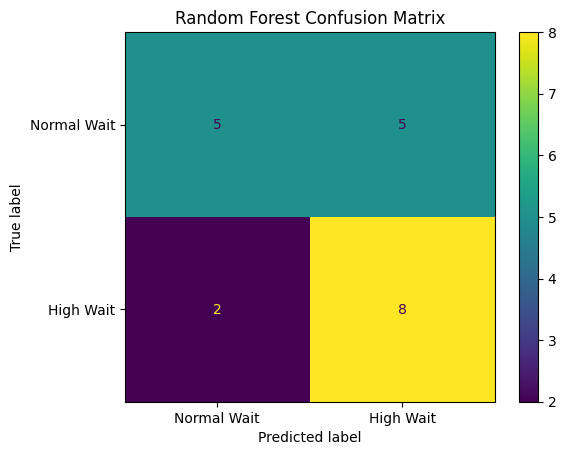

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Wait", "High Wait"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Appointment_Hour,0.199512
24,Appointment_Type_Follow-up,0.092895
7,Doctor_Dr. Divya,0.091950
5,Department_Pediatrics,0.072336
20,Day_Thursday,0.051609
26,Appointment_Type_Walk-in,0.046420
23,Day_Type_Weekend,0.041121
22,Day_Wednesday,0.037739
9,Doctor_Dr. Kumar,0.031793
25,Appointment_Type_Regular,0.029500


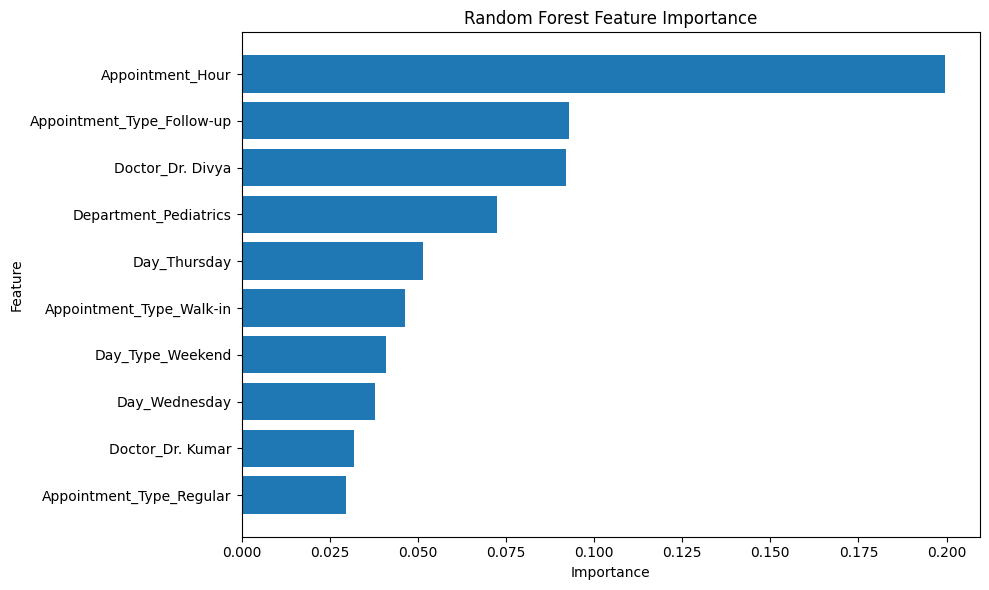

In [53]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [54]:
df.to_csv(
    "hospital_waiting_time_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [55]:
from google.colab import files

files.download("hospital_waiting_time_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
print("Average Registration Waiting:",
      round(df["Registration_Waiting_Min"].mean(), 2), "minutes")

print("Average Doctor Waiting:",
      round(df["Doctor_Waiting_Min"].mean(), 2), "minutes")

print("Average Total Waiting:",
      round(df["Total_Waiting_Min"].mean(), 2), "minutes")

print("Median Total Waiting:",
      round(df["Total_Waiting_Min"].median(), 2), "minutes")

Average Registration Waiting: 17.68 minutes
Average Doctor Waiting: 23.08 minutes
Average Total Waiting: 40.76 minutes
Median Total Waiting: 41.5 minutes


In [57]:
department_summary = df.groupby("Department").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Waiting_Min", "mean"),
    Avg_Doctor_Wait=("Doctor_Waiting_Min", "mean"),
    Avg_Total_Wait=("Total_Waiting_Min", "mean")
).round(2)

department_summary = department_summary.sort_values(
    "Avg_Total_Wait",
    ascending=False
)

department_summary

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Department,,,,
Cardiology,14,15.21,31.86,47.07
General Medicine,26,20.85,23.00,43.85
Orthopedics,15,17.20,26.20,43.40
ENT,14,17.57,23.93,41.50
Dermatology,14,19.21,19.36,38.57
Pediatrics,17,14.12,15.59,29.71


In [58]:
department_summary.sort_values(
    "Avg_Total_Wait",
    ascending=False
).head(3)

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Department,,,,
Cardiology,14,15.21,31.86,47.07
General Medicine,26,20.85,23.00,43.85
Orthopedics,15,17.20,26.20,43.40


In [59]:
registration_avg = df["Registration_Waiting_Min"].mean()
doctor_avg = df["Doctor_Waiting_Min"].mean()

print("Registration waiting:", round(registration_avg, 2), "minutes")
print("Doctor waiting:", round(doctor_avg, 2), "minutes")

if doctor_avg > registration_avg:
    print("Main bottleneck: Doctor waiting")
else:
    print("Main bottleneck: Registration")

Registration waiting: 17.68 minutes
Doctor waiting: 23.08 minutes
Main bottleneck: Doctor waiting


In [60]:
appointment_summary = df.groupby("Appointment_Type").agg(
    Patients=("Patient_ID", "count"),
    Avg_Wait=("Total_Waiting_Min", "mean"),
    Avg_Doctor_Wait=("Doctor_Waiting_Min", "mean")
).round(2)

appointment_summary.sort_values(
    "Avg_Wait",
    ascending=False
)

,Patients,Avg_Wait,Avg_Doctor_Wait
Appointment_Type,,,
Walk-in,20,49.85,21.15
Emergency,12,48.00,25.17
Regular,43,39.58,25.21
Follow-up,25,32.04,19.96


In [61]:
hour_summary = df.groupby("Appointment_Hour").agg(
    Patients=("Patient_ID", "count"),
    Avg_Wait=("Total_Waiting_Min", "mean")
).round(2)

hour_summary.sort_values(
    "Avg_Wait",
    ascending=False
)

,Patients,Avg_Wait
Appointment_Hour,,
10,13,51.62
11,13,47.31
8,7,44.29
9,16,42.56
12,14,38.14
15,12,35.58
16,9,34.56
14,16,32.94


In [62]:
hour_summary.sort_values(
    "Patients",
    ascending=False
)

,Patients,Avg_Wait
Appointment_Hour,,
9,16,42.56
14,16,32.94
12,14,38.14
10,13,51.62
11,13,47.31
15,12,35.58
16,9,34.56
8,7,44.29


In [63]:
weekday_weekend = df.groupby("Day_Type").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Waiting_Min", "mean"),
    Avg_Doctor_Wait=("Doctor_Waiting_Min", "mean"),
    Avg_Total_Wait=("Total_Waiting_Min", "mean")
).round(2)

weekday_weekend

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Day_Type,,,,
Weekday,71,18.48,25.92,44.39
Weekend,29,15.72,16.14,31.86


In [64]:
weekday_wait = weekday_weekend.loc["Weekday", "Avg_Total_Wait"]
weekend_wait = weekday_weekend.loc["Weekend", "Avg_Total_Wait"]

print(
    "Difference in average total waiting:",
    round(abs(weekday_wait - weekend_wait), 2),
    "minutes"
)

Difference in average total waiting: 12.53 minutes


In [65]:
df.nlargest(5, "Total_Waiting_Min")[
    [
        "Patient_ID",
        "Department",
        "Appointment_Type",
        "Day",
        "Appointment_Time",
        "Total_Waiting_Min"
    ]
]

,Patient_ID,Department,Appointment_Type,Day,Appointment_Time,Total_Waiting_Min
19,P026,ENT,Walk-in,Wednesday,2026-08-05 10:45:00,77.0
97,P012,Dermatology,Emergency,Sunday,2026-08-16 10:00:00,77.0
55,P041,Cardiology,Regular,Wednesday,2026-08-12 08:30:00,74.0
24,P053,Pediatrics,Regular,Thursday,2026-08-06 10:15:00,73.0
4,P020,General Medicine,Regular,Monday,2026-08-03 10:15:00,67.0


In [66]:
summary = {
    "Average Registration Waiting": round(df["Registration_Waiting_Min"].mean(), 2),
    "Average Doctor Waiting": round(df["Doctor_Waiting_Min"].mean(), 2),
    "Average Total Waiting": round(df["Total_Waiting_Min"].mean(), 2),
    "Median Total Waiting": round(df["Total_Waiting_Min"].median(), 2),
    "Highest Waiting Department": department_summary.index[0],
    "Highest Waiting Department Avg": department_summary.iloc[0]["Avg_Total_Wait"],
    "Highest Waiting Appointment Type": appointment_summary["Avg_Wait"].idxmax(),
    "Highest Waiting Appointment Type Avg": appointment_summary["Avg_Wait"].max()
}

for key, value in summary.items():
    print(f"{key}: {value}")

Average Registration Waiting: 17.68
Average Doctor Waiting: 23.08
Average Total Waiting: 40.76
Median Total Waiting: 41.5
Highest Waiting Department: Cardiology
Highest Waiting Department Avg: 47.07
Highest Waiting Appointment Type: Walk-in
Highest Waiting Appointment Type Avg: 49.85


In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Random Forest Evaluation
------------------------
Accuracy : 65.0 %
Precision: 61.54 %
Recall   : 80.0 %
F1 Score : 69.57 %


In [68]:
feature_importance.head(10)

,Feature,Importance
0,Appointment_Hour,0.199512
24,Appointment_Type_Follow-up,0.092895
7,Doctor_Dr. Divya,0.091950
5,Department_Pediatrics,0.072336
20,Day_Thursday,0.051609
26,Appointment_Type_Walk-in,0.046420
23,Day_Type_Weekend,0.041121
22,Day_Wednesday,0.037739
9,Doctor_Dr. Kumar,0.031793
25,Appointment_Type_Regular,0.029500


In [69]:
df.to_csv("hospital_waiting_time_final.csv", index=False)

from google.colab import files
files.download("hospital_waiting_time_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>